
# **Telegram** **sentiment_analysis**


In [1]:
!pip install telethon


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 11.5 MB/s eta 0:00:00
  Created wheel for pyaes: filename=pyaes-1.6.1-py3-none-any.whl size=26347 sha256=bb127114cd0fad27d08d67e62a042956ed9a2613250aeff417c734187e2f9ac6
  Stored in directory: /root/.cache/pip/wheels/4e/52/33/010d0843550bffb6a591b11629070ae140c0ad4f53e68a3bd3
Successfully built pyaes


In [2]:
!pip install dateparser


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 14.5 MB/s eta 0:00:00


In [3]:
!pip install pandas nest_asyncio telethon dateparser


In [4]:
!pip install langdetect


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 20.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=c8fda71ae2435b7e76ef7bceb379923372953ba47e35276f9e4b9e0f693c88b8
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect


In [ ]:
import pandas as pd
import nest_asyncio
import asyncio
import re
from datetime import datetime, timedelta
from telethon.sync import TelegramClient
from dateparser.search import search_dates
from langdetect import detect
import os
from pytz import timezone

nest_asyncio.apply()

api_id = os.getenv("TELEGRAM_API_ID", 21764785)
api_hash = os.getenv("TELEGRAM_API_HASH", "a502c9bdf77efd81ad2bb0e3c9c1f8c1")
session_name = "telegram_scraper"

group_names = ["@BITCOIN", "@BITCOINPUMPGROUP", "@BITCOIN_MAGAZINE",
               "@BITCOIN_INSIGHTS", "@BITCOINNEWS", "@CRYPTOCURRENCY_INSIDE",
               "@BITCOINCHARTS", "@COINGRAPHNEWS", "@PORTER_NEWS"]

MIN_DATE = datetime(2009, 1, 1)
MAX_DATE = datetime(2030, 1, 1)

def is_english(text):
    try:
        return detect(text) == "en"
    except:
        return False

def extract_date_from_text(text, post_date):
    parsed_dates = search_dates(text, languages=['en'])
    if parsed_dates:
        valid_dates = [date[1].replace(tzinfo=None) for date in parsed_dates if MIN_DATE <= date[1].replace(tzinfo=None) <= MAX_DATE]
        if valid_dates:
            return min(valid_dates, key=lambda d: abs((d - post_date).days)).strftime("%Y-%m-%d")
    return None

def adjust_date_based_on_keywords(text, post_date, mentioned_date=None):
    patterns = {
        r"\b(today)\b": 0,
        r"\b(yesterday)\b": 1,
        r"\b(last week)\b": 7,
        r"\b(last month)\b": 30,
        r"\b(last year)\b": 365
    }
    for pattern, days in patterns.items():
        if re.search(pattern, text, re.IGNORECASE):
            return (post_date - timedelta(days=days)).strftime("%Y-%m-%d")
    return (mentioned_date if pd.notna(mentioned_date) else post_date).strftime("%Y-%m-%d")


async def get_telegram_messages(group_names, batch_size=5000):
    async with TelegramClient(session_name, api_id, api_hash) as client:
        for group in group_names:
            print(f"Extracting data from: {group}...")
            messages = []
            async for message in client.iter_messages(group):
                if message.text and is_english(message.text):
                    messages.append({
                        "group": group,
                        "date": message.date.strftime("%Y-%m-%d %H:%M:%S"),
                        "text": message.text.strip()
                    })
                if len(messages) >= batch_size:
                    save_to_csv(messages)
                    messages = []
            if messages:
                save_to_csv(messages)

def save_to_csv(data, filename="telegram_bitcoin_english_messages.csv"):
    df = pd.DataFrame(data)
    df["date"] = pd.to_datetime(df["date"], utc=True).dt.tz_localize(None)
    df["mentioned_date"] = df.apply(lambda row: extract_date_from_text(row["text"], row["date"]), axis=1)
    df["mentioned_date"] = pd.to_datetime(df["mentioned_date"], errors='coerce')

    df["final_date"] = df.apply(lambda row:
        adjust_date_based_on_keywords(row["text"], row["mentioned_date"] if pd.notna(row["mentioned_date"]) else row["date"], row["mentioned_date"]), axis=1)

    df["final_date"] = pd.to_datetime(df["final_date"], errors='coerce')
    df.loc[(df["final_date"].isna()) | (df["final_date"] < MIN_DATE) | (df["final_date"] > MAX_DATE), "final_date"] = df["date"]

    df.drop_duplicates(subset=["group", "text"], keep="first", inplace=True)
    df.to_csv(filename, mode='a', header=not os.path.exists(filename), index=False, encoding="utf-8-sig")
    print(f"Saved {len(df)} messages in {filename}")

async def main():
    await get_telegram_messages(group_names)

asyncio.run(main())

Extracting data from: @BITCOIN...
Saved 4946 messages in telegram_bitcoin_english_messages.csv
Saved 4935 messages in telegram_bitcoin_english_messages.csv
Saved 3093 messages in telegram_bitcoin_english_messages.csv
Extracting data from: @BITCOINPUMPGROUP...
Saved 3148 messages in telegram_bitcoin_english_messages.csv
Saved 3186 messages in telegram_bitcoin_english_messages.csv
Saved 3003 messages in telegram_bitcoin_english_messages.csv
Saved 3230 messages in telegram_bitcoin_english_messages.csv
Saved 3678 messages in telegram_bitcoin_english_messages.csv
Saved 3776 messages in telegram_bitcoin_english_messages.csv
Saved 3363 messages in telegram_bitcoin_english_messages.csv
Saved 3036 messages in telegram_bitcoin_english_messages.csv
Saved 3196 messages in telegram_bitcoin_english_messages.csv
Extracting data from: @BITCOIN_MAGAZINE...
Saved 4794 messages in telegram_bitcoin_english_messages.csv
Saved 622 messages in telegram_bitcoin_english_messages.csv
Extracting data from: @BITC

In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import re
from langdetect import detect

device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "yiyanghkust/finbert-tone"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)

sentiment_analysis_pipeline = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, device=0 if device == "cuda" else -1)

def clean_message(message):
    message = re.sub(r'http\S+|www\S+', '', message)
    message = re.sub(r'[^a-zA-Z0-9\s]', '', message)
    message = message.lower().strip()
    return message

def is_english(text):
    try:
        return detect(text) == "en"
    except:
        return False

def filter_bitcoin_messages(messages_df):
    bitcoin_keywords = ['bitcoin', 'btc', 'cryptocurrency', 'crypto', 'blockchain', 'btcprice']

    messages_df = messages_df.copy()
    messages_df['cleaned_text'] = messages_df['text'].apply(clean_message)
    messages_df['is_bitcoin_related'] = messages_df['cleaned_text'].apply(
        lambda x: any(keyword in x for keyword in bitcoin_keywords) and is_english(x)
    )

    return messages_df[messages_df['is_bitcoin_related']].copy()

def analyze_sentiment(text):
    result = sentiment_analysis_pipeline(text[:512])
    return result[0]['label']

messages_df = pd.read_csv("telegram_bitcoin_english_messages.csv")

cleaned_df = filter_bitcoin_messages(messages_df)

cleaned_df['sentiment'] = cleaned_df['cleaned_text'].apply(analyze_sentiment)

print(cleaned_df[['date', 'text', 'sentiment']].head())

cleaned_df.to_csv("bitcoin_sentiment_analysis_cleaned.csv", index=False, encoding="utf-8-sig")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/533 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/226k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

Device set to use cuda:0


model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


                  date                                               text  \
0  2025-02-27 14:30:19  MICHAEL SAYLOR ON BITCOIN VOLATILITY: 🟠  “Bitc...   
1  2025-02-27 13:04:08  NEW: 🟠 Metaplanet Issues 2 Billion JPY in 0% O...   
2  2025-02-27 01:09:06  JUST IN: 🇺🇸 Senator Lummis said tomorrow's fir...   
4  2025-02-26 22:33:17  Send this to people who think it's too late to...   
5  2025-02-26 21:09:46  MICHAEL SAYLOR: 🟠 Last week, $MSTR treasury op...   

  sentiment  
0  Positive  
1   Neutral  
2   Neutral  
4   Neutral  
5   Neutral  


In [ ]:
import pandas as pd
from sklearn.utils import resample


df_neutral = cleaned_df[cleaned_df['sentiment'] == 'Neutral']
df_positive = cleaned_df[cleaned_df['sentiment'] == 'Positive']
df_negative = cleaned_df[cleaned_df['sentiment'] == 'Negative']

df_neutral_downsampled = resample(df_neutral,
                                  replace=False,
                                  n_samples=14000,
                                  random_state=42)

df_balanced = pd.concat([df_neutral_downsampled, df_positive, df_negative])

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_balanced['sentiment'].value_counts())

df_balanced.to_csv("balanced_bitcoin_sentiment.csv", index=False, encoding="utf-8-sig")

cleaned_df = df_balanced


sentiment
Neutral     14000
Positive    10196
Negative     4586
Name: count, dtype: int64


In [ ]:
print(cleaned_df[['date', 'cleaned_text', 'sentiment']].head(50).to_string())


                   date                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     cleaned_text sentiment
0   2022-01-24 22:35:32                                                                                                                                                                                                                                                                                                              

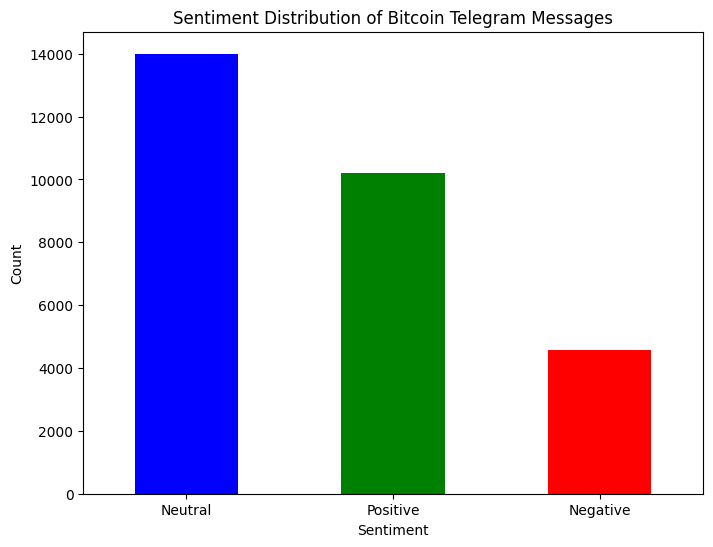

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('balanced_bitcoin_sentiment.csv')

sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(8, 6))
sentiment_counts.plot(kind='bar', color=['blue', 'green', 'red'])
plt.title('Sentiment Distribution of Bitcoin Telegram Messages')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()


In [ ]:
from google.colab import files

file_path = 'balanced_bitcoin_sentiment.csv'

files.download(file_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

data = pd.read_csv('balanced_bitcoin_sentiment.csv')

data['final_date'] = pd.to_datetime(data['final_date'], errors='coerce')

data['year'] = data['final_date'].dt.year

yearly_counts = data['year'].value_counts().sort_index()

print(yearly_counts)


year
2009       15
2010       22
2011       23
2012       17
2013       27
2014       17
2015       47
2016       46
2017      106
2018       91
2019      507
2020      665
2021     3186
2022     2885
2023     2955
2024     6719
2025    11381
2026       45
2027       11
2028       13
2029        4
Name: count, dtype: int64


**bitcoin_tweets**

In [ ]:
import pandas as pd

data = pd.read_csv('bitcoin_tweets1000000.csv', encoding='ISO-8859-1', on_bad_lines='skip', engine='python')

data['date'] = pd.to_datetime(data['date'], errors='coerce')

data_cleaned = data.dropna(subset=['date'])

data_cleaned = data_cleaned.copy()

data_cleaned['year'] = data_cleaned['date'].dt.year

data_2021 = data_cleaned[data_cleaned['year'] == 2021]

data_2021['day'] = data_2021['date'].dt.date

daily_samples = data_2021.groupby('day').apply(lambda x: x.sample(n=100, random_state=42) if len(x) >= 100 else x)


yearly_counts = daily_samples['year'].value_counts().sort_index()



In [ ]:
all_column_names = data_cleaned.columns

print(all_column_names)


Index(['Unnamed: 0', 'user_name', 'user_location', 'user_description',
       'user_created', 'user_followers', 'user_friends', 'user_favourites',
       'user_verified', 'date', 'text', 'hashtags', 'source', 'is_retweet',
       'cleanText', 'Polarity Score', 'sentiment', 'year'],
      dtype='object')


In [ ]:
daily_samples['sentiment'].value_counts()


,count
sentiment,
0.0,3984
1.0,3216


In [ ]:
print(data_cleaned[['date', 'cleanText', 'sentiment']].head(55))


                  date                                          cleanText  \
0  2021-02-10 23:59:04  blue ridge bank shares halted nyse bitcoin atm...   
1  2021-02-10 23:58:48  today thursday take friend leowandersleb btc w...   
2  2021-02-10 23:54:48     guys evening read article btc would like share   
3  2021-02-10 23:54:33    btc big chance billion price bitcoin btc crypto   
4  2021-02-10 23:54:06  network secured nodes today soon biggest bears...   
5  2021-02-10 23:53:30  trade crypto binance enjoy cashback trading fe...   
6  2021-02-10 23:53:17                    fire amp man bitcoin crypto btc   
7  2021-02-10 23:52:42                 prices update eur hour btc eth xrp   
8  2021-02-10 23:52:25  btc bitcoin ethereum eth crypto cryptotrading ...   
9  2021-02-10 23:52:08  tesla bitcoin investment revolutionary crypto ...   
10 2021-02-10 23:52:04               annnd btc bitcoin headed even higher   
11 2021-02-10 23:51:25                prices update usdt hour btc eth xrp   

# **kaggel  dataset tweets**

In [ ]:
!pip install datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 19.6 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset

ds = load_dataset("ckandemir/bitcoin_tweets_sentiment_kaggle")

README.md:   0%|          | 0.00/3.87k [00:00<?, ?B/s]

(…)-00000-of-00001-cc8461398e266567.parquet:   0%|          | 0.00/7.92M [00:00<?, ?B/s]

(…)-00000-of-00001-922aa10406034550.parquet:   0%|          | 0.00/997k [00:00<?, ?B/s]

(…)-00000-of-00001-dc793d916ae447cb.parquet:   0%|          | 0.00/949k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/77791 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/9724 [00:00<?, ? examples/s]

Generating eval split:   0%|          | 0/9724 [00:00<?, ? examples/s]

In [ ]:
import pandas as pd

ds = load_dataset("ckandemir/bitcoin_tweets_sentiment_kaggle")

df = ds['train'].to_pandas()

print(df.columns)
print(df.head())

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['year'] = df['Date'].dt.year

yearly_distribution = df['year'].value_counts().sort_index()

print(yearly_distribution)


Index(['Date', 'text', 'Sentiment'], dtype='object')
         Date                                               text Sentiment
0  2019-06-12  Are you interested in Bitcoin mining for FREE!...  Positive
1  2019-07-08  QA Analyst - IT Services Company ( WESTBURY, U...  Positive
2  2019-05-22  🌍22/05/2019🌍\nA Abakus a qual a NovaDAX perten...  Negative
3  2019-05-16  @Quark_Chain #QKC #Blockchain #BTC #ETH #block...  Negative
4  2018-07-21  July 21, 2018 04:00 AM EDT\nLast 4 hours, BTC ...  Positive
year
2014      766
2015     1491
2016     2801
2017     7586
2018    17284
2019    47863
Name: count, dtype: int64


In [ ]:
import re
from dateutil.parser import parse
from datetime import timedelta
import pandas as pd
from dateparser.search import search_dates

MIN_DATE = pd.to_datetime("2010-01-01")
MAX_DATE = pd.to_datetime("2023-12-31")

def extract_date_from_text(text, post_date):
    parsed_dates = search_dates(text, languages=['en'])
    if parsed_dates:
        valid_dates = [date[1].replace(tzinfo=None) for date in parsed_dates if MIN_DATE <= date[1].replace(tzinfo=None) <= MAX_DATE]
        if valid_dates:
            return min(valid_dates, key=lambda d: abs((d - post_date).days)).strftime("%Y-%m-%d")
    return None

def adjust_date_based_on_keywords(text, post_date, mentioned_date=None):
    patterns = {
        r"\b(today)\b": 0,
        r"\b(yesterday)\b": 1,
        r"\b(last week)\b": 7,
        r"\b(last month)\b": 30,
        r"\b(last year)\b": 365
    }
    for pattern, days in patterns.items():
        if re.search(pattern, text, re.IGNORECASE):
            return (post_date - timedelta(days=days)).strftime("%Y-%m-%d")
    return (mentioned_date if pd.notna(mentioned_date) else post_date).strftime("%Y-%m-%d")

def process_data(df):
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

    df['adjusted_date'] = df.apply(lambda row: extract_date_from_text(row['text'], row['Date'])
                                   if pd.isna(row['Date']) else row['Date'], axis=1)

    df['final_date'] = df.apply(lambda row: adjust_date_based_on_keywords(row['text'], row['adjusted_date']), axis=1)

    return df



df = process_data(df)

print(df[['Date', 'text', 'final_date']].head())


        Date                                               text  final_date
0 2019-06-12  Are you interested in Bitcoin mining for FREE!...  2019-06-12
1 2019-07-08  QA Analyst - IT Services Company ( WESTBURY, U...  2019-07-08
2 2019-05-22  🌍22/05/2019🌍\nA Abakus a qual a NovaDAX perten...  2019-05-22
3 2019-05-16  @Quark_Chain #QKC #Blockchain #BTC #ETH #block...  2019-05-16
4 2018-07-21  July 21, 2018 04:00 AM EDT\nLast 4 hours, BTC ...  2018-07-21


In [ ]:
print(df[['Date', 'text', 'final_date']].head(50))

         Date                                               text  final_date
0  2019-06-12  Are you interested in Bitcoin mining for FREE!...  2019-06-12
1  2019-07-08  QA Analyst - IT Services Company ( WESTBURY, U...  2019-07-08
2  2019-05-22  🌍22/05/2019🌍\nA Abakus a qual a NovaDAX perten...  2019-05-22
3  2019-05-16  @Quark_Chain #QKC #Blockchain #BTC #ETH #block...  2019-05-16
4  2018-07-21  July 21, 2018 04:00 AM EDT\nLast 4 hours, BTC ...  2018-07-21
5  2019-07-11  As of July 10, 2019 at 09:50AM, 1 BTC = 11671....  2019-07-11
6  2017-12-08                                bitcoin priceってゆうか、  2017-12-08
7  2019-05-14  FIRST 100 MEMBERS WILL BE ALLOWED\n\nJoin : ht...  2019-05-14
8  2019-06-14  I want to drop a kind word in favour of to thi...  2019-06-14
9  2019-07-01  https://t.co/utvdy6QR4r\nClick the link\nSign ...  2019-07-01
10 2016-02-09  LIVE: Profit = $8.63 (0.78 %). BUY B2.95 @ $37...  2016-02-09
11 2018-04-07  STOP BUYING #ALTCOINS YOU FUCKING MORONS \nSo ...  2018-04-07

In [ ]:

print(df.head())


        Date                                               text Sentiment  \
0 2019-06-12  Are you interested in Bitcoin mining for FREE!...  Positive   
1 2019-07-08  QA Analyst - IT Services Company ( WESTBURY, U...  Positive   
2 2019-05-22  🌍22/05/2019🌍\nA Abakus a qual a NovaDAX perten...  Negative   
3 2019-05-16  @Quark_Chain #QKC #Blockchain #BTC #ETH #block...  Negative   
4 2018-07-21  July 21, 2018 04:00 AM EDT\nLast 4 hours, BTC ...  Positive   

   year adjusted_date  final_date  
0  2019    2019-06-12  2019-06-12  
1  2019    2019-07-08  2019-07-08  
2  2019    2019-05-22  2019-05-22  
3  2019    2019-05-16  2019-05-16  
4  2018    2018-07-21  2018-07-21  


In [ ]:
df.to_csv("processed_bitcoin_data.csv", index=False, encoding="utf-8-sig")


In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import re
from langdetect import detect

device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "yiyanghkust/finbert-tone"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)

sentiment_analysis_pipeline = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, device=0 if device == "cuda" else -1)

def clean_message(message):
    message = re.sub(r'http\S+|www\S+', '', message)
    message = re.sub(r'[^a-zA-Z0-9\s]', '', message)
    message = message.lower().strip()
    return message

def is_english(text):
    try:
        return detect(text) == "en"
    except:
        return False

def filter_bitcoin_messages(messages_df):
    bitcoin_keywords = ['bitcoin', 'btc', 'cryptocurrency', 'crypto', 'blockchain', 'btcprice']

    messages_df = messages_df.copy()
    messages_df['cleaned_text'] = messages_df['text'].apply(clean_message)
    messages_df['is_bitcoin_related'] = messages_df['cleaned_text'].apply(
        lambda x: any(keyword in x for keyword in bitcoin_keywords) and is_english(x)
    )

    return messages_df[messages_df['is_bitcoin_related']].copy()

def analyze_sentiment(text):
    result = sentiment_analysis_pipeline(text[:512])
    return result[0]['label']

messages_df = pd.read_csv("processed_bitcoin_data.csv")

cleaned_df = filter_bitcoin_messages(messages_df)

cleaned_df['f_sentiment'] = cleaned_df['cleaned_text'].apply(analyze_sentiment)

print(cleaned_df[['final_date', 'text', 'f_sentiment']].head())

cleaned_df.to_csv("processed_bitcoin_data_with_finBERT.csv", index=False, encoding="utf-8-sig")


Device set to use cuda:0


   final_date                                               text f_sentiment
0  2019-06-12  Are you interested in Bitcoin mining for FREE!...     Neutral
1  2019-07-08  QA Analyst - IT Services Company ( WESTBURY, U...     Neutral
3  2019-05-16  @Quark_Chain #QKC #Blockchain #BTC #ETH #block...     Neutral
4  2018-07-21  July 21, 2018 04:00 AM EDT\nLast 4 hours, BTC ...     Neutral
5  2019-07-11  As of July 10, 2019 at 09:50AM, 1 BTC = 11671....     Neutral


# **Bitcoin_tweets**

In [ ]:
!pip install swifter


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 15.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for swifter: filename=swifter-1.4.0-py3-none-any.whl size=16507 sha256=dc61243b316f596250b7ca5e047c0065a3241e3eccffbe6ccaddfc1b5930d27e
  Stored in directory: /root/.cache/pip/wheels/ef/7f/bd/9bed48f078f3ee1fa75e0b29b6e0335ce1cb03a38d3443b3a3
Successfully built swifter


In [ ]:
import re
import pandas as pd
import swifter
from datetime import timedelta
from dateparser.search import search_dates

# تحميل البيانات
data = pd.read_csv('Bitcoin_tweets.csv', on_bad_lines='skip', engine='python')

data['date'] = pd.to_datetime(data['date'], errors='coerce')

data_cleaned = data.dropna(subset=['date'])

MIN_DATE = pd.Timestamp("2010-01-01")
MAX_DATE = pd.Timestamp("2023-12-31")

def extract_date_from_text(text, post_date):
    parsed_dates = search_dates(text, languages=['en']) if isinstance(text, str) else None
    if parsed_dates:
        valid_dates = [date[1].replace(tzinfo=None) for date in parsed_dates if MIN_DATE <= date[1].replace(tzinfo=None) <= MAX_DATE]
        if valid_dates:
            return min(valid_dates, key=lambda d: abs((d - post_date).days)).strftime("%Y-%m-%d")
    return None

def adjust_date_based_on_keywords(text, post_date, extracted_date=None):
    patterns = {
        r"\b(today)\b": 0,
        r"\b(yesterday)\b": 1,
        r"\b(last week)\b": 7,
        r"\b(last month)\b": 30,
        r"\b(last year)\b": 365
    }
    for pattern, days in patterns.items():
        if re.search(pattern, text, re.IGNORECASE):
            return (post_date - timedelta(days=days)).strftime("%Y-%m-%d")

    return extracted_date if extracted_date else post_date.strftime("%Y-%m-%d")

data_cleaned['extracted_date'] = data_cleaned.swifter.apply(
    lambda row: extract_date_from_text(row['text'], row['date']), axis=1
)

data_cleaned['final_date'] = data_cleaned.swifter.apply(
    lambda row: adjust_date_based_on_keywords(row['text'], row['date'], row['extracted_date']), axis=1
)

data_cleaned['year'] = pd.to_datetime(data_cleaned['final_date'], errors='coerce').dt.year


data_cleaned.to_csv("Processed_Bitcoin_Tweets.csv", index=False, encoding="utf-8-sig")


Pandas Apply:   0%|          | 0/48583 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/48583 [00:00<?, ?it/s]

In [ ]:
print(data_cleaned[['date', 'text', 'final_date']].head(50))

                  date                                               text  \
0  2021-02-10 23:59:04  Blue Ridge Bank shares halted by NYSE after #b...   
1  2021-02-10 23:58:48  😎 Today, that's this #Thursday, we will do a "...   
2  2021-02-10 23:54:48  Guys evening, I have read this article about B...   
3  2021-02-10 23:54:33  $BTC A big chance in a billion! Price: \487264...   
4  2021-02-10 23:54:06  This network is secured by 9 508 nodes as of t...   
5  2021-02-10 23:53:30  💹 Trade #Crypto on #Binance \n\n📌 Enjoy #Cashb...   
6  2021-02-10 23:53:17  &lt;'fire' &amp; 'man'&gt;\n#Bitcoin #Crypto #...   
7  2021-02-10 23:52:42  🔄 Prices update in $EUR (1 hour):\n\n$BTC   - ...   
8  2021-02-10 23:52:25  #BTC #Bitcoin #Ethereum #ETH #Crypto #cryptotr...   
9  2021-02-10 23:52:08  .@Tesla’s #bitcoin investment is revolutionary...   
10 2021-02-10 23:52:04  Annnd #btc #Bitcoin is headed even higher now....   
11 2021-02-10 23:51:25  🔄 Prices update in $USDT (1 hour):\n\n$BTC - 4...   

In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import re
from langdetect import detect

device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "yiyanghkust/finbert-tone"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)

sentiment_analysis_pipeline = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, device=0 if device == "cuda" else -1)

# دالة لتنظيف الرسائل
def clean_message(message):
    message = re.sub(r'http\S+|www\S+', '', message)
    message = re.sub(r'[^a-zA-Z0-9\s]', '', message)
    message = message.lower().strip()
    return message

def is_english(text):
    try:
        return detect(text) == "en"
    except:
        return False

def filter_bitcoin_messages(messages_df):
    bitcoin_keywords = ['bitcoin', 'btc', 'cryptocurrency', 'crypto', 'blockchain', 'btcprice']

    messages_df = messages_df.copy()
    messages_df['cleaned_text'] = messages_df['text'].apply(clean_message)
    messages_df['is_bitcoin_related'] = messages_df['cleaned_text'].apply(
        lambda x: any(keyword in x for keyword in bitcoin_keywords) and is_english(x)
    )

    return messages_df[messages_df['is_bitcoin_related']].copy()

def analyze_sentiment(text):
    result = sentiment_analysis_pipeline(text[:512])
    return result[0]['label']

messages_df = pd.read_csv("Processed_Bitcoin_Tweets.csv")

cleaned_df = filter_bitcoin_messages(messages_df)

cleaned_df['f_sentiment'] = cleaned_df['cleaned_text'].apply(analyze_sentiment)

print(cleaned_df[['final_date', 'text', 'f_sentiment']].head())

cleaned_df.to_csv("processed_bitcoin_Tweets.csv", index=False, encoding="utf-8-sig")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/533 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/226k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

Device set to use cuda:0


model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


   final_date                                               text f_sentiment
0  2021-02-10  Blue Ridge Bank shares halted by NYSE after #b...     Neutral
1  2021-02-10  😎 Today, that's this #Thursday, we will do a "...     Neutral
2  2021-02-10  Guys evening, I have read this article about B...     Neutral
3  2021-02-11  $BTC A big chance in a billion! Price: \487264...     Neutral
4  2021-02-10  This network is secured by 9 508 nodes as of t...     Neutral


In [ ]:
# تحويل العمود 'final_date' إلى نوع تاريخي
cleaned_df['final_date'] = pd.to_datetime(cleaned_df['final_date'])

# استخراج السنة من التاريخ
cleaned_df['year'] = cleaned_df['final_date'].dt.year

# حساب عدد التصنيفات لكل سنة
sentiment_by_year = cleaned_df.groupby(['year', 'f_sentiment']).size().unstack(fill_value=0)

print("عدد التصنيفات لكل سنة:")
print(sentiment_by_year)


عدد التصنيفات لكل سنة:
f_sentiment  Negative  Neutral  Positive
year                                    
2010                1       22         0
2011                0       25         0
2012                0        7         0
2013                1       40         0
2014                0       41         1
2015               13       20         8
2016                1       12         0
2017               15       82        15
2018                6       31         2
2019                1       15         1
2020               14       95        12
2021             1499    31462      4731
2022                2       22         0
2023                0       12         1


# **bitcoin_news**

In [ ]:
from datasets import load_dataset

ds = load_dataset("edaschau/bitcoin_news")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/695 [00:00<?, ?B/s]

BTC_yahoo.csv:   0%|          | 0.00/396M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/80806 [00:00<?, ? examples/s]

In [ ]:
import pandas as pd

ds = load_dataset("edaschau/bitcoin_news")
df = ds['train'].to_pandas()

print(df.columns)
print(df.head())

df['date_time'] = pd.to_datetime(df['date_time'], errors='coerce')

df['year'] = df['date_time'].dt.year

yearly_distribution = df['year'].value_counts().sort_index()

print(yearly_distribution)


Index(['time_unix', 'date_time', 'text_matches', 'title_matches', 'title',
       'url', 'source', 'source_url', 'article_text'],
      dtype='object')
    time_unix                  date_time  \
0  1308740160  2011-06-22 10:56:00+00:00   
1  1328119352  2012-02-01 18:02:32+00:00   
2  1332444236  2012-03-22 19:23:56+00:00   
3  1345679880  2012-08-22 23:58:00+00:00   
4  1347025081  2012-09-07 13:38:01+00:00   

                                        text_matches      title_matches  \
0                  {"Bitcoin": [0, 967, 1184, 1227]}  {"Bitcoin": [37]}   
1           {"Bitcoin": [18, 195, 1871, 2827, 3683]}   {"Bitcoin": [0]}   
2  {"Bitcoin": [562, 705, 981, 1064, 2068, 2221, ...  {"Bitcoin": [56]}   
3                                 {"Bitcoin": [450]}                 {}   
4                          {"Bitcoin": [1231, 5352]}                 {}   

                                               title  \
0  Compromised account leads to massive Bitcoin s...   
1          Bitcoin M

In [ ]:
import re
import pandas as pd
from datetime import timedelta
from dateparser.search import search_dates
from datasets import load_dataset

ds = load_dataset("edaschau/bitcoin_news")
df = ds['train'].to_pandas()

MIN_DATE = pd.Timestamp("2010-01-01")
MAX_DATE = pd.Timestamp("2023-12-31")

df['date_time'] = pd.to_datetime(df['date_time'], errors='coerce')

def fast_extract_date(text):
    parsed_dates = search_dates(text, languages=['en']) if isinstance(text, str) else None
    if parsed_dates:
        valid_dates = [date[1].replace(tzinfo=None) for date in parsed_dates if MIN_DATE <= date[1].replace(tzinfo=None) <= MAX_DATE]
        return min(valid_dates, default=None)
    return None

df['extracted_date'] = df['article_text'].map(fast_extract_date)

def adjust_date(text, post_date, extracted_date):
    if pd.isna(post_date):
        return None

    post_date = pd.Timestamp(post_date).replace(tzinfo=None)

    patterns = {
        r"\b(today)\b": 0,
        r"\b(yesterday)\b": 1,
        r"\b(last week)\b": 7,
        r"\b(last month)\b": 30,
        r"\b(last year)\b": 365
    }

    for pattern, days in patterns.items():
        if re.search(pattern, text, re.IGNORECASE):
            return (post_date - timedelta(days=days)).strftime("%Y-%m-%d")

    return extracted_date.strftime("%Y-%m-%d") if pd.notna(extracted_date) else post_date.strftime("%Y-%m-%d")

df['final_date'] = df.apply(lambda row: adjust_date(row['article_text'], row['date_time'], row['extracted_date']), axis=1)

df['year'] = pd.to_datetime(df['final_date'], errors='coerce').dt.year

yearly_distribution = df['year'].value_counts().sort_index()

print(yearly_distribution)

df.to_csv("fast_processed_bitcoin_news.csv", index=False, encoding="utf-8-sig")


year
2010.0      624
2011.0      799
2012.0     1038
2013.0     1538
2014.0     1845
2015.0     1730
2016.0     1506
2017.0     5508
2018.0    11591
2019.0     7434
2020.0     6540
2021.0    17566
2022.0    14510
2023.0     7869
2024.0      705
Name: count, dtype: int64


In [ ]:
from google.colab import files
files.download("fast_processed_bitcoin_news.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.to_csv('processed_bitcoin_news.csv', index=False)


In [ ]:
print(df.head(50))


     time_unix                 date_time  \
0   1308740160 2011-06-22 10:56:00+00:00   
1   1328119352 2012-02-01 18:02:32+00:00   
2   1332444236 2012-03-22 19:23:56+00:00   
3   1345679880 2012-08-22 23:58:00+00:00   
4   1347025081 2012-09-07 13:38:01+00:00   
5   1347025081 2012-09-07 13:38:01+00:00   
6   1351512372 2012-10-29 12:06:12+00:00   
7   1354314715 2012-11-30 22:31:55+00:00   
8   1355040540 2012-12-09 08:09:00+00:00   
9   1359420420 2013-01-29 00:47:00+00:00   
10  1361479019 2013-02-21 20:36:59+00:00   
11  1361987994 2013-02-27 17:59:54+00:00   
12  1363020265 2013-03-11 16:44:25+00:00   
13  1363975628 2013-03-22 18:07:08+00:00   
14  1364482495 2013-03-28 14:54:55+00:00   
15  1364498580 2013-03-28 19:23:00+00:00   
16  1364532971 2013-03-29 04:56:11+00:00   
17  1364828460 2013-04-01 15:01:00+00:00   
18  1364849700 2013-04-01 20:55:00+00:00   
19  1364882411 2013-04-02 06:00:11+00:00   
20  1364902680 2013-04-02 11:38:00+00:00   
21  1364912340 2013-04-02 14:19:

In [ ]:
import pandas as pd

df_telegram = pd.read_csv('balanced_bitcoin_sentiment.csv')
df_twitter = pd.read_csv('processed_bitcoin_data_with_finBERT.csv')
df_threads = pd.read_csv('processed_bitcoin_Tweets.csv')
df_twitter2 = pd.read_csv('sentiment_data.csv')
df_other2 = pd.read_csv('processed_bitcoin_data_with_finBERT (1).csv')

print("Telegram Dataset Columns:")
print(df_telegram.columns)

print("\nTwitter Dataset Columns:")
print(df_twitter.columns)

print("\nThreads Dataset Columns:")
print(df_threads.columns)

print("\nOther1 Dataset Columns:")
print(df_twitter2.columns)

print("\nOther2 Dataset Columns:")
print(df_other2.columns)


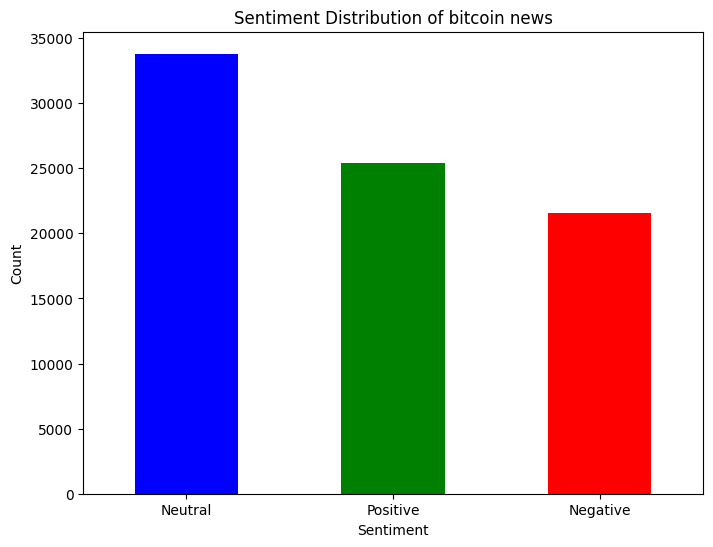

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('processed_bitcoin_data_with_finBERT.csv')

sentiment_counts = df['f_sentiment'].value_counts()

plt.figure(figsize=(8, 6))
sentiment_counts.plot(kind='bar', color=['blue', 'green', 'red'])
plt.title('Sentiment Distribution of bitcoin news')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()
